In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from PIL import Image

img = Image.open("mona_lisa_public_domain.jpg")
print(img.size)

(2403, 3591)


In [5]:
img = img.convert("L")

width, height = img.size
new_height = 360
new_width = round(width * new_height / height)
img = img.resize((new_width, new_height))

X = np.asarray(img, dtype=float)
X = X / 255

In [6]:
n, p = X.shape
rank = np.linalg.matrix_rank(X)

print("n =", n)
print("p =", p)
print("rank(X) =", rank)
print("intensity range =", (X.min(), X.max()))

n = 360
p = 241
rank(X) = 241
intensity range = (np.float64(0.06274509803921569), np.float64(0.7529411764705882))


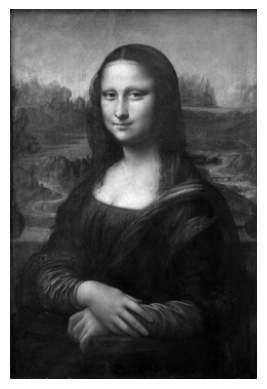

In [7]:
plt.imshow(X, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
Sigma = np.diag(S)
V = Vt.T

U_error = np.linalg.norm(U.T @ U - np.eye(U.shape[1]), 2)
V_error = np.linalg.norm(V.T @ V - np.eye(V.shape[1]), 2)
reconstruction_error = np.linalg.norm(X - U @ Sigma @ Vt, "fro") / np.linalg.norm(X, "fro")

print("||U^T U - I||_2 =", U_error)
print("||V^T V - I||_2 =", V_error)
print("Relative reconstruction error =", reconstruction_error)

||U^T U - I||_2 = 4.792944677889678e-15
||V^T V - I||_2 = 5.189572645108745e-15
Relative reconstruction error = 6.644654239955792e-15


In [9]:
k = 1

Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

Xk = Uk @ Sk @ Vtk

print(Xk.shape)

(360, 241)


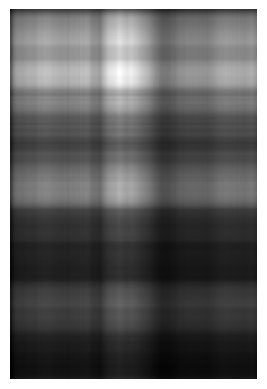

In [10]:
plt.imshow(np.clip(Xk, 0, 1), cmap="gray")
plt.axis("off")
plt.show()

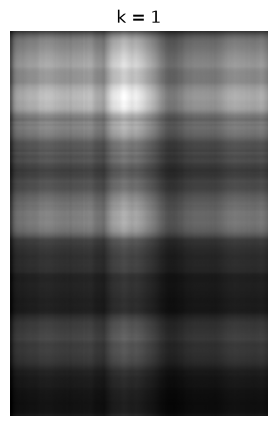

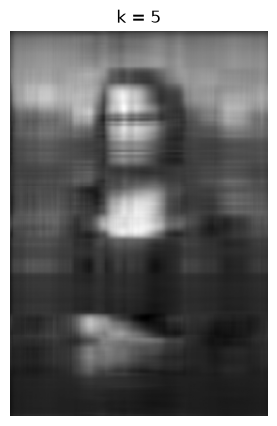

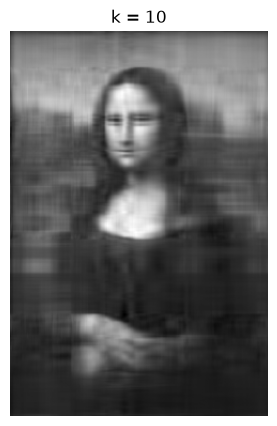

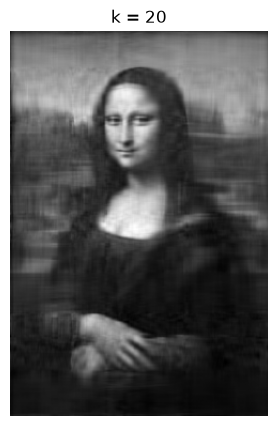

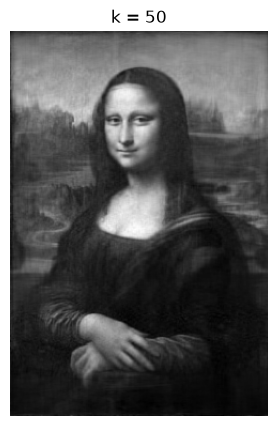

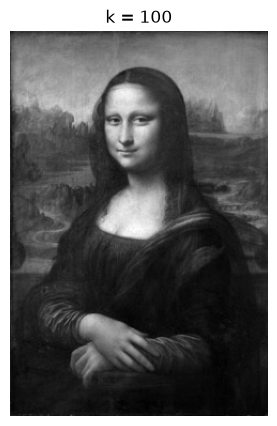

In [11]:
ks = [1, 5, 10, 20, 50, 100]

for k in ks:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    
    Xk = Uk @ Sk @ Vtk
    Xk_display = np.clip(Xk, 0, 1)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(Xk_display, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")
    plt.show()

In [12]:
ks = [1, 5, 10, 20, 50, 100]

for k in ks:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    
    Xk = Uk @ Sk @ Vtk
    
    actual_error = np.linalg.norm(X - Xk, "fro")
    theoretical_error = np.sqrt(np.sum(S[k:]**2))
    
    print(f"k = {k}")
    print("Actual error:", actual_error)
    print("Theoretical error:", theoretical_error)
    print("Difference:", abs(actual_error - theoretical_error))
    print()

k = 1
Actual error: 26.099967090462588
Theoretical error: 26.099967090462577
Difference: 1.0658141036401503e-14

k = 5
Actual error: 12.191919711474602
Theoretical error: 12.191919711474604
Difference: 1.7763568394002505e-15

k = 10
Actual error: 7.837508140654032
Theoretical error: 7.837508140654032
Difference: 0.0

k = 20
Actual error: 5.061121261895914
Theoretical error: 5.061121261895914
Difference: 0.0

k = 50
Actual error: 2.7564118010944583
Theoretical error: 2.7564118010944587
Difference: 4.440892098500626e-16

k = 100
Actual error: 1.3942609048183838
Theoretical error: 1.3942609048183838
Difference: 0.0



In [13]:
S_squared = S**2
total_energy = np.sum(S_squared)
cumulative_energy = np.cumsum(S_squared)
energy_share = cumulative_energy / total_energy

thresholds = [0.90, 0.95, 0.99]

for threshold in thresholds:
    k = np.argmax(energy_share >= threshold) + 1
    relative_error = np.sqrt(1 - energy_share[k - 1])
    
    print(f"{threshold*100:.0f}% energy:")
    print("Smallest k =", k)
    print("Retained energy =", energy_share[k - 1])
    print("Relative Frobenius error =", relative_error)
    print()

90% energy:
Smallest k = 1
Retained energy = 0.9066256712247722
Relative Frobenius error = 0.305572133505704

95% energy:
Smallest k = 3
Retained energy = 0.964746946588326
Relative Frobenius error = 0.1877579649753212

99% energy:
Smallest k = 9
Retained energy = 0.9903011037452856
Relative Frobenius error = 0.09848297444083637

